In [40]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import numpy as np
from tqdm.auto import tqdm
from data_fitting.module_fitzcu import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.254"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_sg_int4_v2 - envelope memory 16384 samples (38.095 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 3

In [3]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12\Loop'

# Connect yoko

In [180]:
client = Labber.connectToServer('localhost', timeout=86400)
yoko_connect='0x0B21::0x0039::91WB18861'
yoko_global = client.connectToInstrument(
    'Yokogawa GS200 DC Source', dict(
        interface='USB', address=(yoko_connect))
)
yoko_global_cfg = {
    'Current - Sweep rate': 50e-6,
    'Function': 'Current',
    'Range (I)': '10mA',
    'Output': True,
}
yoko_global.setValue(sQuant='Output', value=True)

True

In [181]:
Yoko_current = 2.5 # [mA]
yoko_global.setValue(sQuant='Current', value=Yoko_current*1e-3, rate=10e-6)

0.0025

# System config

In [42]:
r1 = 5352.79
r2 = 5494.19
r3 = 5667.69
r4 = 5796.46
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]
res_mixer = round(np.sum(r)/6)
res_mixer=5800
q1, q2, q3, q4, q5, q6 = [2, 0, 1, 7, 0, 14]
q = [q1, q2, q3, q4, q5, q6]

In [43]:
config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': r,
          'mixer_freq': res_mixer,
          'res_gains': [0.5]*6,
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 5,
          'ro_len': 5,
          'relax_delay':50
         }

qb_cfg={
    'qb_ch':q,
    'f_q': 4200,
    'qmixer_freq': 4200,
    'q_len':5,
    'q_gain': 0.01,
    'sigma': 0.5,
}

config = {**config, **qb_cfg}

  0%|          | 0/1000 [00:00<?, ?it/s]

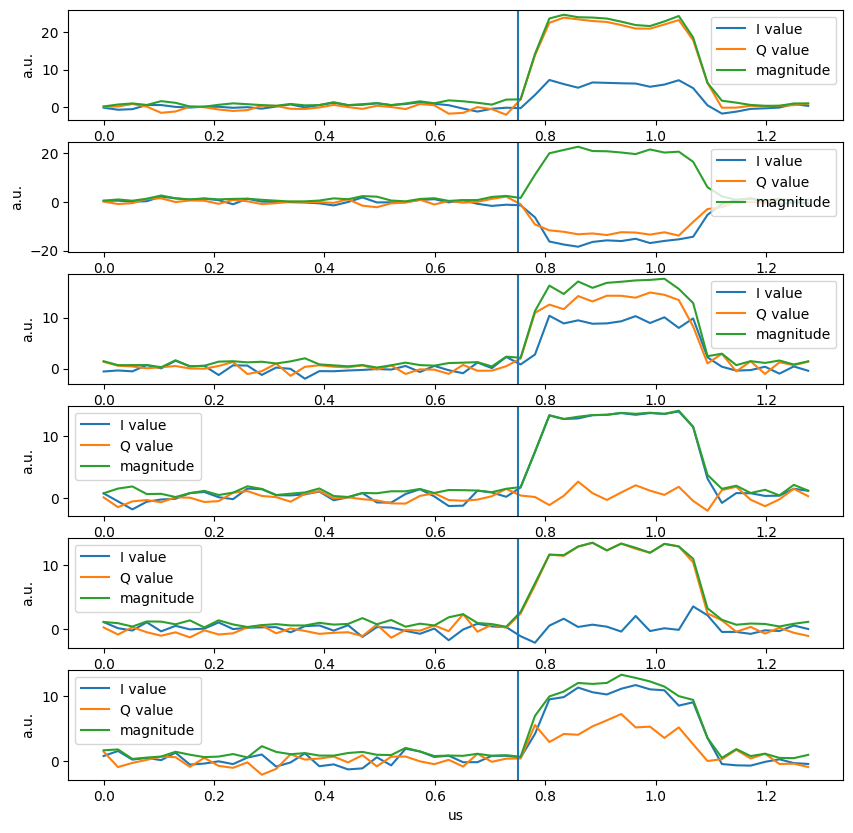

In [6]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
config.update({
    'res_len': 0.3, 
    'ro_len':1.3, 
    'res_gains': [1.0]*6, 
    'res_freqs':np.array(r)-15, 
    'trig_time': 0}) 


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=config)
iq_list = prog.acquire_decimated(soc, soft_avgs=1000)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(10,10))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


# for i, ch in enumerate(config['ro_chs']):
#     # frequency-matching cross-check
#     f_gen = prog.res_chs[config['res_ch']]['mux_tones'][i]['freq_rounded']
#     f_ro = prog.ro_chs[ch]['ro_config']['f_rounded']
#     print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

# Mux OneTone

In [44]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



In [49]:
n_roch = 6
F_Span = 10
F_Steps = 101

sweep = np.linspace(-F_Span, F_Span, F_Steps)
z_list = [[] for _ in range(6)]  
config['res_gains'] = [0.2] * n_roch

for i in tqdm(sweep):
    config['res_freqs'] = np.array(r) + i
    prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=config)
    results = prog.acquire(soc, soft_avgs=50, progress=False)
    for idx, res in enumerate(results):
        z_list[idx].append(res[0][0] + 1j * res[0][1])

  0%|          | 0/101 [00:00<?, ?it/s]

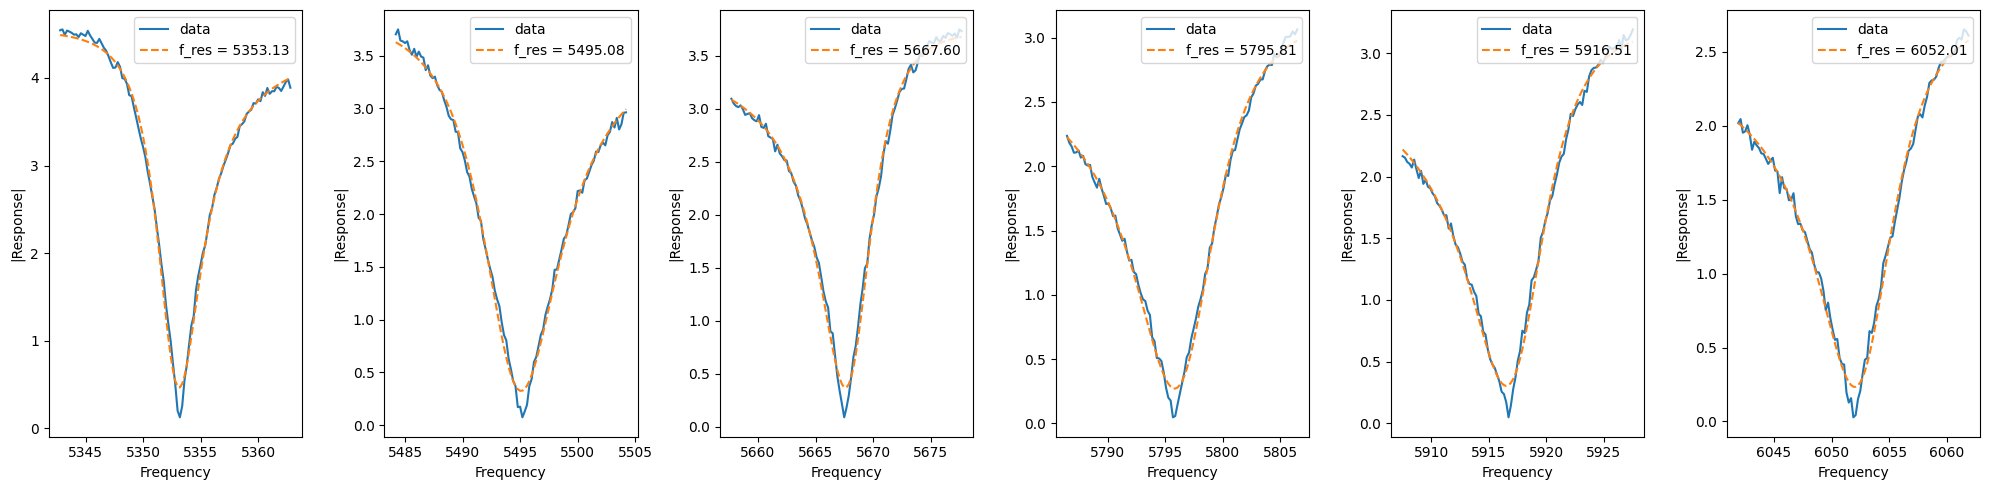

In [50]:
popt = [[] for _ in range(n_roch)]
fit_res = [[]] * n_roch


fig, ax = plt.subplots(1, n_roch, figsize=(20,5))

for i in range(n_roch):
    freq_sweep = r[i] + sweep
    mag_response = np.abs(z_list[i])

    ax[i].plot(freq_sweep, mag_response, label='data')
    popt[i], _ = fit_asym_lor(freq_sweep, mag_response)
    ax[i].plot(freq_sweep, asym_lorfunc(freq_sweep, *popt[i]), '--', label=f'f_res = {popt[i][2]:.2f}')
    ax[i].legend(loc='upper right')
    ax[i].set_xlabel('Frequency')
    ax[i].set_ylabel('|Response|')
    fit_res[i] = round(popt[i][2], 2)

plt.tight_layout()
plt.show()

In [ ]:
data_path = data_path

for idx in range(n_roch):
        exp_name = f"res onetone mux r{idx}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + sweep)*1e6},  

                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(x[idx])},
                comment=f'',
                tag='OneTone'
        )

## Mux OneTone Punchout

In [47]:
class MuxPunchout(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0, 1, 2, 3, 4, 5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)


In [48]:
n_roch=6
F_Sapn = 20
F_Steps = 51

G_Start = 0.02
G_Stop = 1
G_Steps = 51
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
gain = np.linspace(G_Start, G_Stop, G_Steps)  

outer_loop = tqdm(gain, desc="Gain Sweep")
z = [] 
for g in outer_loop:
    config['res_gains'] = [g] * n_roch
    amps = []  

    for f in (fpts):
        config['res_freqs'] = np.array(r) + f
        prog = MuxPunchout(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)
    z.append(np.array(amps))
z = np.array(z)  


Gain Sweep:   0%|          | 0/51 [00:00<?, ?it/s]

KeyboardInterrupt: 

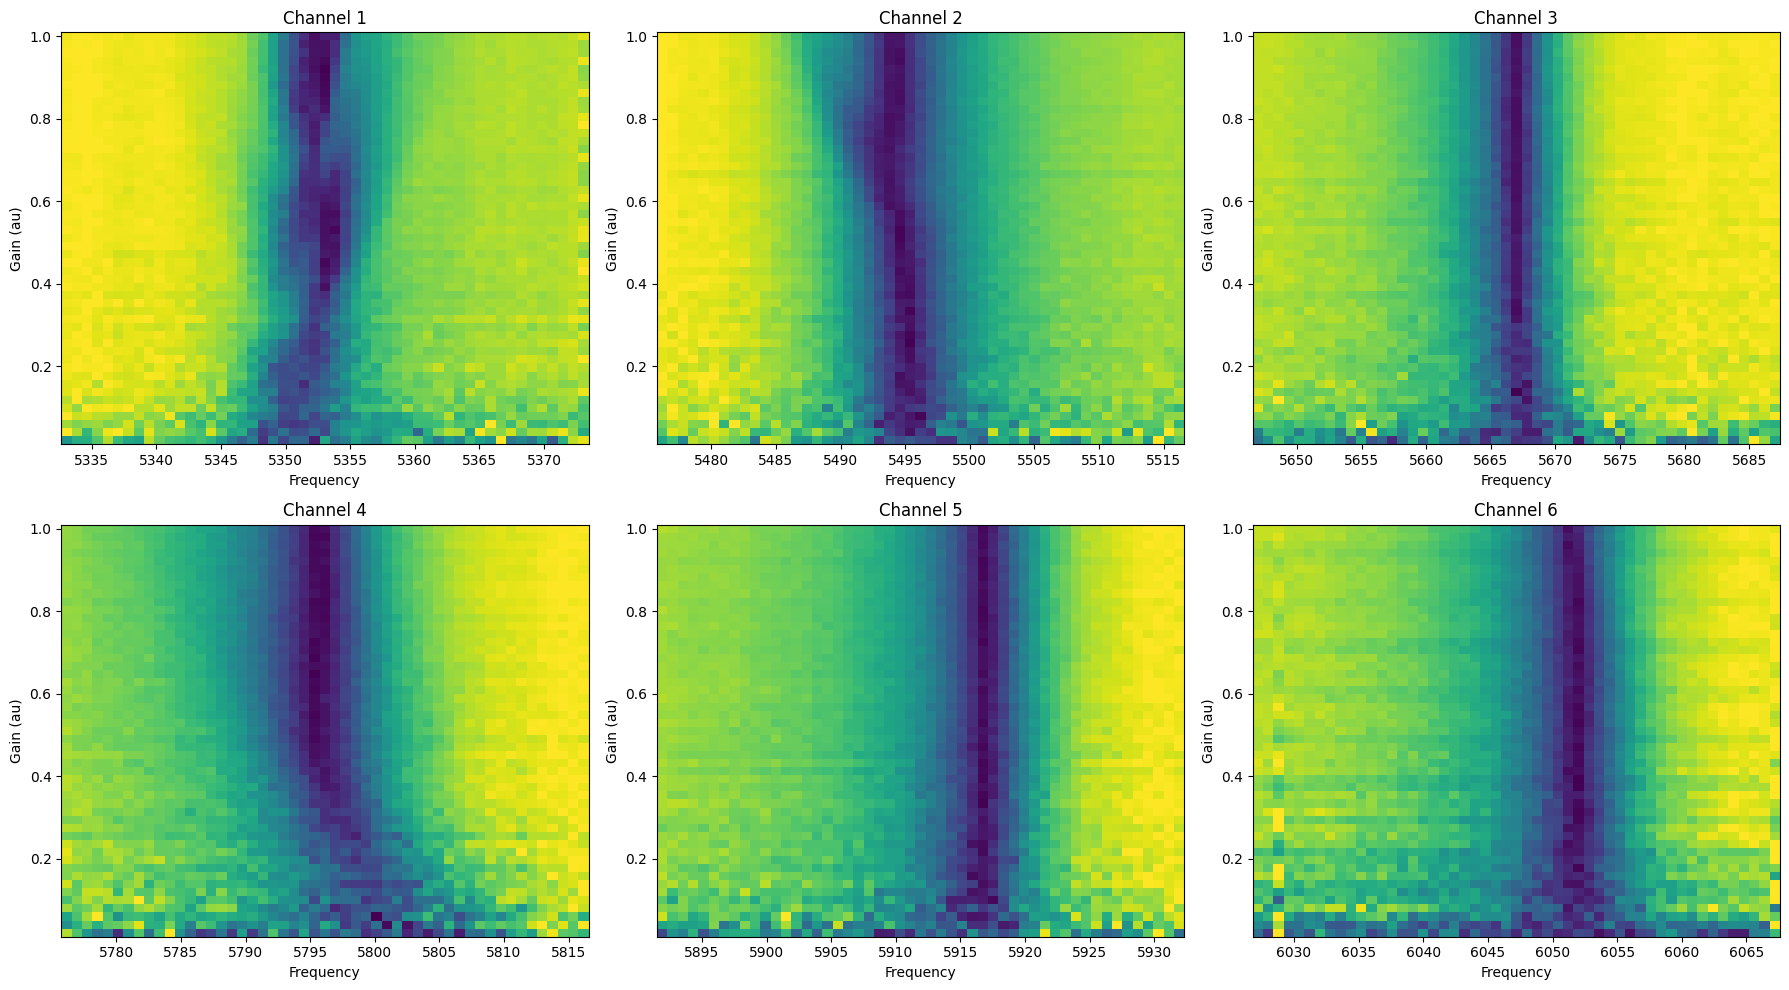

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_roch):
    data = np.abs(z[:, :, idx]) 
    norm_data = np.zeros_like(data)
    for i in range(data.shape[0]):  
        max_val = np.max(data[i])
        if max_val != 0:
            norm_data[i] = data[i] / max_val  
        else:
            norm_data[i] = data[i]  
    pcm = axes[idx].pcolormesh(r[idx] + fpts, gain, norm_data, shading='auto')
    axes[idx].set_title(f'Channel {idx+1}')
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()

In [ ]:
data_path = data_path

for idx in range(6):
        exp_name = f"res pdr mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + fpts)*1e6},  
                y_info={'name': 'DAC Gain', 'unit': "a.u",
                        'values': gain},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z[:, :, idx])},
                comment=f'',
                tag='OneTone'
        )

## Mux OneTone Flux

In [ ]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



In [278]:
n_roch = 6

F_Sapn = 15
F_Steps = 51

Curr_Start = 6
Curr_Stop = -2
Curr_Step = 161
config['res_gains'] = [0.2] * n_roch
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
flux = np.linspace(Curr_Start, Curr_Stop, Curr_Step) * 1e-3

z = []

outer_loop = tqdm(flux, desc="Flux Sweep")

for curr in outer_loop:
    yoko_global.setValue(sQuant='Current', value=curr, rate=50e-6)

    amp_per_flux = []

    inner_loop = tqdm(total=len(sweep), desc=f"Freq Sweep (Flux={curr*1e3:.2f} mA)", leave=False)

    for i in sweep:
        config['res_freqs'] = np.array(r) + i
        prog = MuxOneTone(soccfg, reps=100, final_delay=0.1, cfg=config)
        results = prog.acquire(soc, soft_avgs=20, progress=False)

        amp_per_freq = []

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amp_per_flux.append(amp_per_freq)

    inner_loop.close()

    z.append(np.array(amp_per_flux))

z = np.array(z)

Flux Sweep: 100%|██████████| 161/161 [1:03:13<00:00, 23.56s/it]


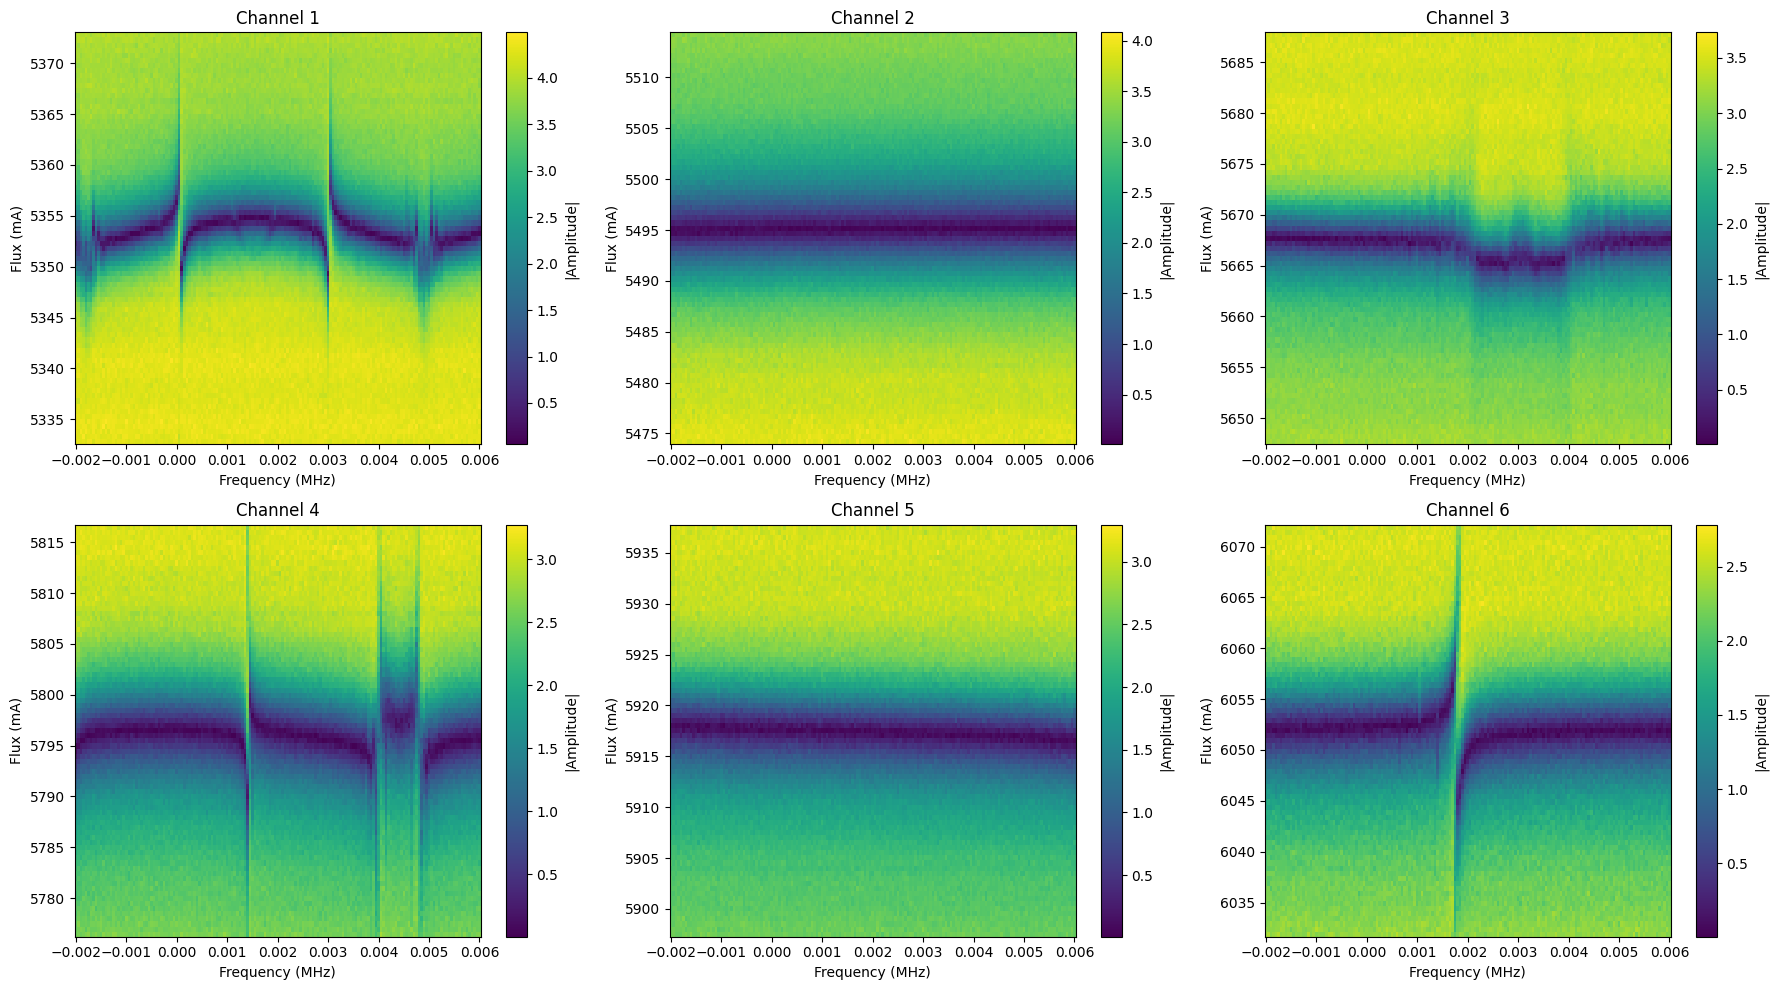

In [279]:
freqs = np.array(r)[:, None] + sweep[None, :]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx in range(n_roch):
    pcm = axes[idx].pcolormesh(
        flux, freqs[idx], 
        np.abs(z[:, :, idx]).T,
        shading='auto'
    )
    axes[idx].set_title(f'Channel {idx+1}')
    axes[idx].set_xlabel('Frequency (MHz)')
    axes[idx].set_ylabel('Flux (mA)')
    fig.colorbar(pcm, ax=axes[idx], label='|Amplitude|')

plt.tight_layout()
plt.show()


In [280]:
data_path = data_path

for idx in range(6):
        exp_name = f"res flux mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (freqs[idx])*1e6},  
                y_info={'name': 'yoko current', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z[:, :, idx])},
                comment=f'',
                tag='OneTone'
        )

## Aiming One resonator

In [ ]:
class MuxOneToneFocus(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)

config = {'res_ch': 12,
          'ro_chs': [2],
          'pulse_freqs': r,
          'mixer_freq': 5750,
          'pulse_gains': [0.15],
          'pulse_phases': [0.0],
          'ro_phases': [0.0],
          'trig_time': 0.7,
          'pulse_len': 1.0,
          'ro_len': 1.2,
         }


100%|██████████| 51/51 [00:05<00:00,  9.53it/s]


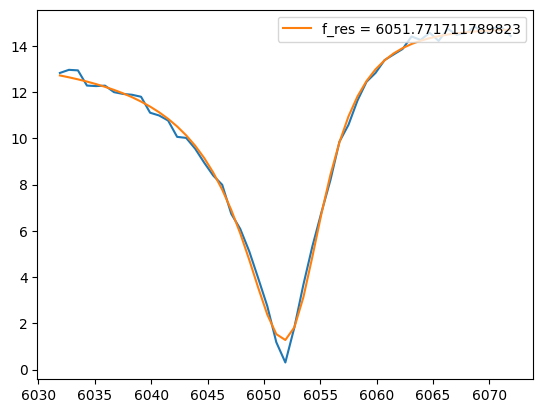

In [ ]:
res_idx = 5

initial = [r[res_idx]]
sweep = np.linspace(-20, 20, 51)
z1=[]

config['pulse_gains'] = [0.15]
for i in tqdm(sweep):
    config['pulse_freqs'] = np.array(initial)+i
    prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.5, cfg=config)
    x1, = prog.acquire(soc, soft_avgs=10, progress=False)
    z1.append(x1[0][0]+1j*x1[0][1])

## Plot ##
plt.plot(initial + sweep, np.abs(z1))
popt,_ = fit_asym_lor(initial + sweep, np.abs(z1))
plt.plot(initial + sweep, asym_lorfunc(initial + sweep, *popt), label=f'f_res = {popt[2]}')
plt.legend(loc='upper right')
res_freq = round(popt[2], 2)

## Punch out

In [ ]:
initial = [r[res_idx]]
sweep_f = np.linspace(-20, 20, 41)  # freq sweep points
sweep_g = np.linspace(0.02, 1, 20)  # gain sweep points


z = [] 

outer_loop = tqdm(sweep_g, desc="Gain Sweep")

for g in outer_loop:
    config['pulse_gains'] = [g] 
    amps = []  

    for f in (sweep_f):
        config['pulse_freqs'] = np.array(initial) + f

        prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)

    z.append(np.array(amps))

z = np.array(z)  # z.shape = (n_gain, n_freq, n_roch)


Gain Sweep: 100%|██████████| 20/20 [01:21<00:00,  4.06s/it]


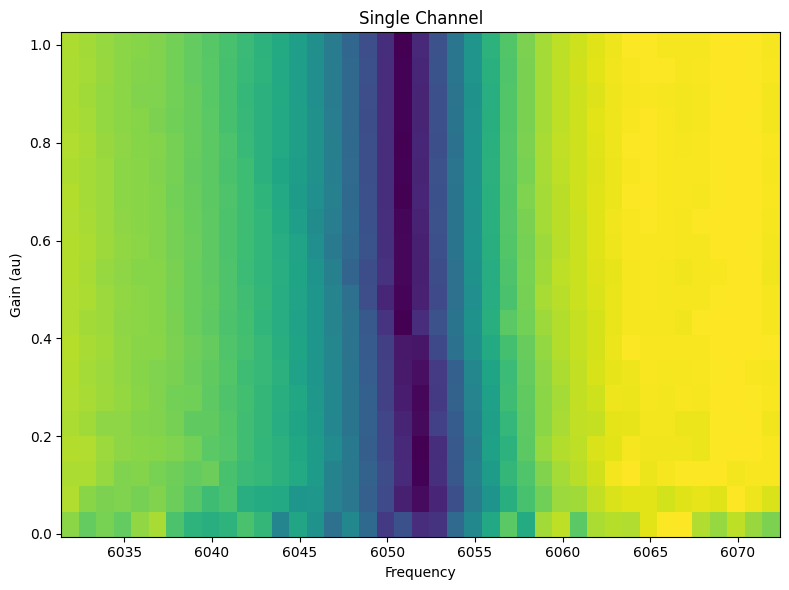

In [ ]:
fpts = sweep_f
gain = sweep_g

fig, ax = plt.subplots(figsize=(8, 6))  


data = np.abs(z[:, :, 0]) 

norm_data = np.zeros_like(data)
for i in range(data.shape[0]):  
    max_val = np.max(data[i])
    if max_val != 0:
        norm_data[i] = data[i] / max_val  
    else:
        norm_data[i] = data[i]

pcm = ax.pcolormesh(np.array(initial) + sweep_f, sweep_g, norm_data, shading='auto')

ax.set_title('Single Channel')
ax.set_xlabel('Frequency')
ax.set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()


In [ ]:
data_path = data_path
exp_name = f"res pdr R{res_idx+1}"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': fpts*1e6},  
        y_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gain},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  z[:, :, 0]},
        comment=f'flux at half flux',
        tag='OneTone'
)

# Mux Two Tone

In [51]:
class MuxTwoTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("floop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                        style="flat_top",
                        envelope=f'ramp{i}',
                        freq=cfg[f'f_q{i+1}'],
                        phase= 0,
                        gain=cfg['q_gain'][i],
                        length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }

span = 50
step = 100

qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q1': 2738 + QickSweep1D("floop", -span, span),
    'f_q4': 2935 + QickSweep1D("floop", -span, span),
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': [0.3, 0, 0, 0.1, 0.0, 0.],
    'sigma':0.05
}

run_cfg = {**config, **qb_cfg}


In [52]:
prog = MuxTwoTone(soccfg, reps=100, final_delay=0.1, cfg=run_cfg)
# iq_list = prog.acquire(soc, soft_avgs=100)
freqs = [[]]*6
for idx in [0,3]:
    freqs[idx]= prog.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)

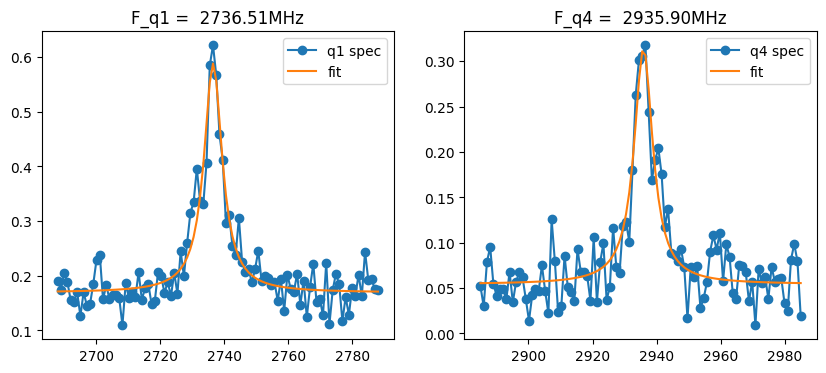

In [53]:
from data_fitting.fitting import lorfunc, fitlor

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

py_avg = 50
iq_sum = [None, None]
iq_avg = [None, None]
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}
for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(freqs[i], np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)
f_q = [[] for _ in range(6)]
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(freqs[i], np.abs(iq_avg[idx]), marker='o', label=f'q{i+1} spec')
    pOpt, _ = fitlor(freqs[i], np.abs(iq_avg[idx]))
    axes[idx].plot(freqs[i], lorfunc(freqs[i], *pOpt), label='fit')

    axes[idx].legend()
    axes[idx].set_title(f'F_q{i+1} =  {pOpt[2]:.2f}MHz')
    f_q[i] = round(pOpt[2],2)


In [115]:
from yamltool import yml_comment
data_path = data_path
try:
        run_cfg.pop('f_q1')
        run_cfg.pop('f_q4')
except:
        pass
config_info = yml_comment(run_cfg)
for idx, i in enumerate([0, 3]):
        exp_name = f"qubit mux spec q{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (freqs[i])*1e6},  
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(iq_avg[idx])},
                comment=f'{config_info}',
                tag='TwoTone'
        )

## Mux Two channe flux spec

In [ ]:

Start_flux = 6 # [mA]
Stop_flux = -2 # [mA]
Steps = 161
### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps)*1e-3


iqlist=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=10e-6)
    qspec = MuxTwoTone(soccfg, reps=100, final_delay= 0.01, cfg=run_cfg)
    iq_list = qspec.acquire(soc, soft_avgs=50, progress=False)

    iqlist.append(iq_list)
iqlist = np.array(iqlist)

100%|██████████| 51/51 [1:07:41<00:00, 79.64s/it]


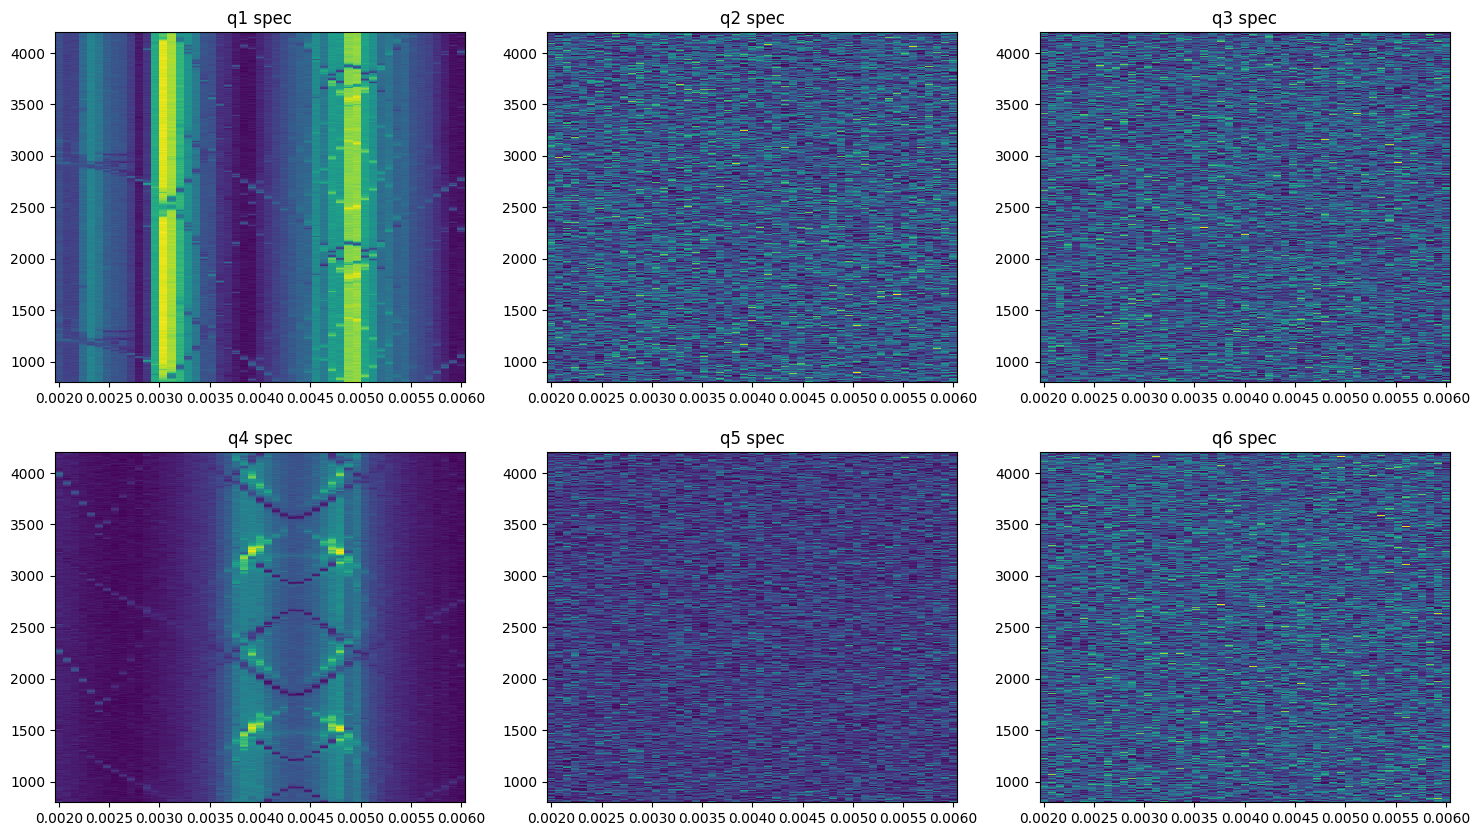

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
freqs = [[]]*6
for idx in range(6):
    freqs[idx]= qspec.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)
axes = axes.flatten()
q_fit=[[]]*6
for i in range(6):
    axes[i].set_title(f'q{i+1} spec')
    axes[i].pcolormesh(flux, freqs[i], np.abs(iqlist[:,i,0].dot([1,1j])).T)

In [ ]:
data_path = data_path
for i in range(6):
        exp_name = f"qubit{i} flux spec"


        file_path = get_next_filename_labber(data_path, exp_name)

        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': freqs[i]*1e6},  
                y_info={'name': 'Flux', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values':  np.array(iqlist)[:, i, 0].dot([1, 1j])},
                        
                comment=f'',
                tag='TwoTone mux'
        )


# PowerRabi

In [54]:
class MuxPowerRabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("gloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }

step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': QickSweep1D('gloop', 0, 1),
    'sigma':0.17
}

run_cfg = {**config, **qb_cfg}


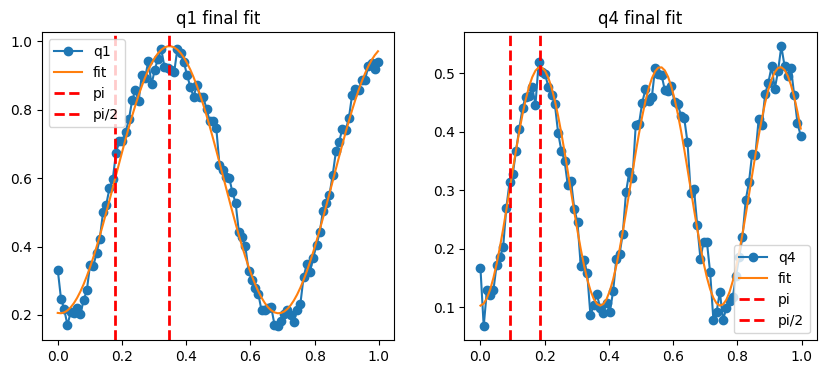

In [ ]:
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

prog = MuxPowerRabi(soccfg, reps=100, final_delay=100, cfg=run_cfg)
gains = prog.get_pulse_param('qb0_pulse', 'gain', as_array=True)

py_avg = 100
iq_sum = [None, None]
iq_avg = [None, None]

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(gains, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} Power Rabi average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)
prabi_fit = [[] for _ in range(6)]
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(gains, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1}')
    pOpt, _ = fitdecaysin(gains, np.abs(iq_avg[idx]))
    axes[idx].plot(gains, decaysin(gains, *pOpt), label='fit')
    pi_gain, pi2_gain = pipulse_analyze(pOpt)
    axes[idx].axvline(pi_gain, ls='--', lw=2, color='r', label='pi')
    axes[idx].axvline(pi2_gain, ls='--', lw=2, color='r', label='pi/2')
    axes[idx].legend()
    axes[idx].set_title(f'q{i+1} Rabi fit')
    prabi_fit[i] = [round(pi_gain, 3), round(pi2_gain, 3)]

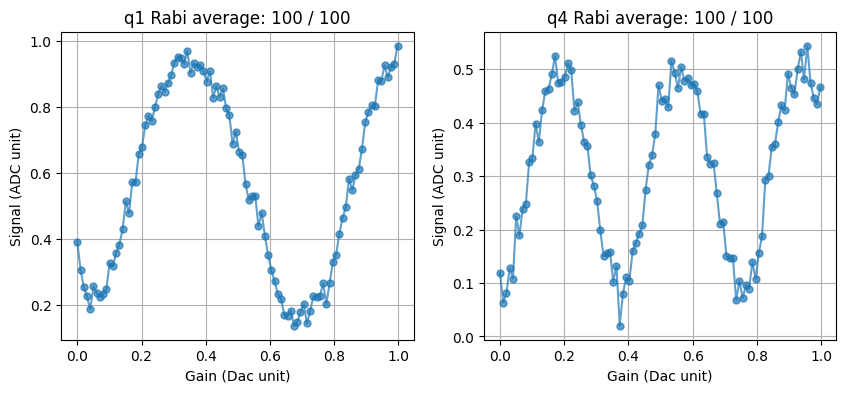

✅ GIF saved to rabi_liveplot.gif


In [61]:
import os
import imageio.v2 as imageio
from PIL import Image

# 建立儲存圖的資料夾
os.makedirs("rabi_frames", exist_ok=True)
frame_paths = []

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(gains, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} Rabi average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)

    # 儲存成圖片
    frame_path = f"rabi_frames/frame_{avg:03d}.png"
    fig.savefig(frame_path)
    frame_paths.append(frame_path)

    clear_output(wait=True)
    display(fig)

# --- 組成 gif ---
gif_path = "rabi_liveplot.gif"
with imageio.get_writer(gif_path, mode='I', duration=2) as writer:
    for f in frame_paths:
        image = Image.open(f)
        writer.append_data(image)

print(f"✅ GIF saved to {gif_path}")






In [62]:
clear_output(wait=True)
prabi_fit = [[] for _ in range(6)]
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(gains, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1}')
    pOpt, _ = fitdecaysin(gains, np.abs(iq_avg[idx]))
    axes[idx].plot(gains, decaysin(gains, *pOpt), label='fit')
    pi_gain, pi2_gain = pipulse_analyze(pOpt)
    axes[idx].axvline(pi_gain, ls='--', lw=2, color='r', label='pi')
    axes[idx].axvline(pi2_gain, ls='--', lw=2, color='r', label='pi/2')
    axes[idx].legend()
    axes[idx].grid(True)
    axes[idx].set_title(f'q{i+1} Rabi fit')
    prabi_fit[i] = [round(pi_gain, 3), round(pi2_gain, 3)]
# --- 加入 Rabi fitting 的最後一幀到 GIF ---
final_frame_path = "rabi_frames/frame_final_fit.png"
fig.savefig(final_frame_path)
frame_paths.append(final_frame_path)

with imageio.get_writer("rabi_liveplot.gif", mode='I', duration=2) as writer:
    for f in frame_paths:
        image = Image.open(f)
        writer.append_data(image)

In [28]:
from yamltool import yml_comment
data_path = data_path
try:
        run_cfg.pop('q_gain')

except:
        pass
config_info = yml_comment(run_cfg)
for idx, i in enumerate([0, 3]):
        exp_name = f"qubit power rabi q{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Gains', 'unit': "Dac unit",
                        'values': gains},  
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(iq_avg[idx])},
                comment=f'{config_info}',
                tag='Rabi'
        )

# Ramsey

In [38]:
class MuxRamsey(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )

    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
            self.delay_auto(cfg['wait_time'], tag=f'wait{i}')
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.3, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.17,
    'wait_time': QickSweep1D('waitloop', 0, 2),
    'ramsey_freq':3
}

run_cfg = {**config, **qb_cfg}


Attempted to init fitparam 1 to 18.278400000000012, which is out of bounds 0.054303030303030304 to 16.29090909090909. Instead init to 8.17260606060606


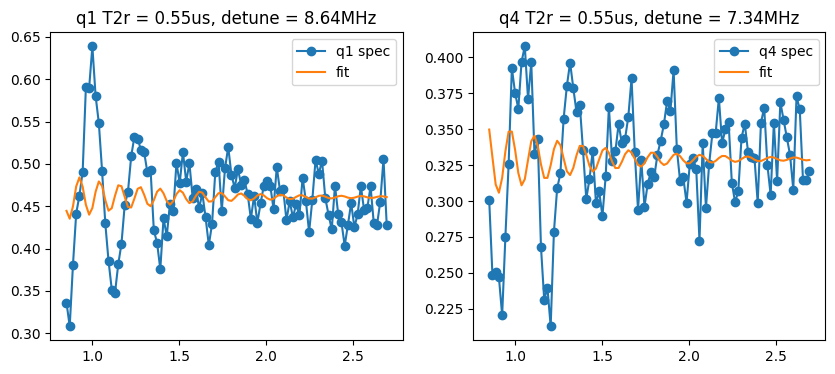

In [39]:
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

prog = MuxRamsey(soccfg, reps=100, final_delay=100, cfg=run_cfg)

delay = prog.get_time_param('wait0', "t", as_array=True)

py_avg = 100
iq_sum = [None, None]
iq_avg = [None, None]

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(delay, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)

detune_fit=[[]]*6
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(delay, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1} spec')
    pOpt, _ = fitdecaysin(delay, np.abs(iq_avg[idx]))
    axes[idx].plot(delay, decaysin(delay, *pOpt), label='fit')
    axes[idx].set_title(f'q{i+1} T2r = {pOpt[3]:.2f}us, detune = {pOpt[1]:.2f}MHz')
    axes[idx].legend()
    detune_fit[i] = round(pOpt[1],3)


In [18]:
activate_correct=True
for idx, i in enumerate([0,3]):
    pOpt, _ = fitdecaysin(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    if activate_correct:
        if abs(pOpt[1]-run_cfg['ramsey_freq'])>0.1:
            f_q[i] -= round(pOpt[1]-run_cfg['ramsey_freq'],2)
            print(f'q{+1} over detune {round((pOpt[1]-run_cfg["ramsey_freq"]),2)}')
        else:
            print(f'q{+1} over detune {round((pOpt[1]-run_cfg["ramsey_freq"]),2)}')

q1 over detune 12.03
q1 over detune -1.57


# T1

In [767]:
class MuxT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)
            self.delay_auto(cfg['wait_time'], tag=f'wait{i}')

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.3, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 70
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.12,
    'wait_time': QickSweep1D('waitloop', 0, 150),
    'ramsey_freq':2
}

run_cfg = {**config, **qb_cfg}


In [768]:
prog = MuxT1(soccfg, reps=200, final_delay=150, cfg=run_cfg)
iq_list = prog.acquire(soc, soft_avgs=50)
delay = prog.get_time_param('wait0', "t", as_array=True)

  0%|          | 0/50 [00:00<?, ?it/s]

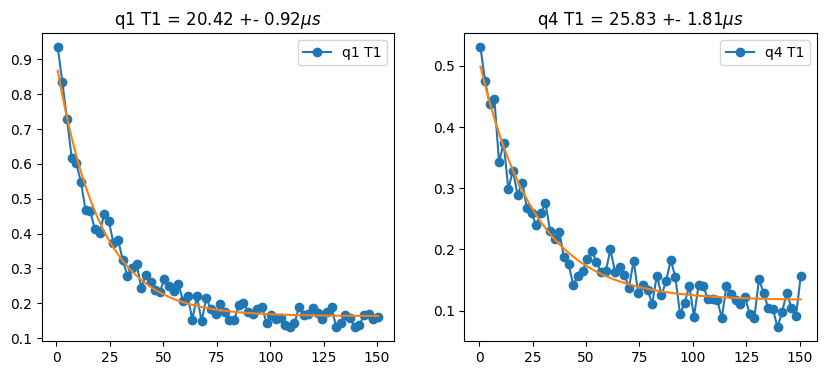

In [769]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for idx, i in enumerate([0,3]):
    axes[idx].plot(delay, np.abs(iq_list[i][0].dot([1,1j])), marker='o', label = f'q{i+1} T1')
    pOpt, pCov = fitexp(delay,  np.abs(iq_list[i][0].dot([1,1j]))) 
    p_sigma = np.sqrt(np.diag(pCov))
    axes[idx].plot(delay, expfunc(delay, *pOpt))
    axes[idx].set_title(f'q{i+1} T1 = {pOpt[3]:.2f} +- {p_sigma[3]:.2f}$\mu s$')
    axes[idx].legend()

In [ ]:
import pandas as pd
import numpy as np
import time
import os

# CSV 檔名與欄位
csv_filename = "Q14_T1_T2_results.csv"
columns = ["Timestamp", "Qubit", "T1 (us)", "T1 sigma", "T2 (us)", "T2 sigma"]

# 如果檔案不存在就寫入欄位標題
if not os.path.exists(csv_filename):
    with open(csv_filename, 'w') as f:
        f.write(",".join(columns) + "\n")

try:
    while True:
        for i in [0, 3]:
            qubit_label = "Qubit1" if i == 0 else "Qubit4"
            timestamp = time.strftime('%Y-%m-%d %H:%M:%S')

            # T1 測量
            run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 80), 'step': 100})
            t1 = MuxT1(soccfg, reps=100, final_delay=100, cfg=run_cfg)
            t1_iq_list = t1.acquire(soc, soft_avgs=100, progress=False)
            t1_delay = t1.get_time_param('wait0', "t", as_array=True)
            t1pOpt, t1pCov = fitexp(t1_delay, np.abs(t1_iq_list[i][0].dot([1, 1j])))
            t1_sigma = np.sqrt(np.diag(t1pCov))

            # T2 測量
            run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 2), 'step': 50})
            t2 = MuxRamsey(soccfg, reps=100, final_delay=100, cfg=run_cfg)
            t2_iq_list = t2.acquire(soc, soft_avgs=100, progress=False)
            t2_delay = t2.get_time_param('wait0', "t", as_array=True)
            t2pOpt, t2pCov = fitdecaysin(t2_delay, np.abs(t2_iq_list[i][0].dot([1, 1j])))
            t2_sigma = np.sqrt(np.diag(t2pCov))

            # 將資料列寫入 CSV（追加模式）
            with open(csv_filename, 'a') as f:
                f.write(f"{timestamp},{qubit_label},{t1pOpt[3]:.6f},{t1_sigma[3]:.6f},{t2pOpt[3]:.6f},{t2_sigma[3]:.6f}\n")

            print(f"[{timestamp}] ✅ {qubit_label} 測量完成: T1 = {t1pOpt[3]:.2f} ± {t1_sigma[3]:.2f} μs, T2 = {t2pOpt[3]:.2f} ± {t2_sigma[3]:.2f} μs")

except KeyboardInterrupt:
    print("\n🔁 測量停止（使用者中斷）")
    print("✅ CSV 資料保存在：", csv_filename)


[2025-05-07 02:44:16] ✅ Qubit1 測量完成: T1 = 21.73 ± 1.34 μs, T2 = 1.11 ± 0.17 μs
[2025-05-07 02:47:45] ✅ Qubit4 測量完成: T1 = 27.24 ± 2.74 μs, T2 = 1.11 ± 0.18 μs
[2025-05-07 02:51:15] ✅ Qubit1 測量完成: T1 = 20.58 ± 1.25 μs, T2 = 1.05 ± 0.15 μs
[2025-05-07 02:54:45] ✅ Qubit4 測量完成: T1 = 21.06 ± 1.76 μs, T2 = 1.22 ± 0.23 μs
[2025-05-07 02:58:16] ✅ Qubit1 測量完成: T1 = 21.04 ± 1.22 μs, T2 = 1.14 ± 0.19 μs
[2025-05-07 03:01:46] ✅ Qubit4 測量完成: T1 = 21.75 ± 1.87 μs, T2 = 1.11 ± 0.21 μs
[2025-05-07 03:05:17] ✅ Qubit1 測量完成: T1 = 20.19 ± 1.12 μs, T2 = 1.11 ± 0.19 μs
[2025-05-07 03:08:47] ✅ Qubit4 測量完成: T1 = 34.21 ± 3.39 μs, T2 = 1.13 ± 0.24 μs
[2025-05-07 03:12:18] ✅ Qubit1 測量完成: T1 = 18.35 ± 1.09 μs, T2 = 1.03 ± 0.19 μs
[2025-05-07 03:15:48] ✅ Qubit4 測量完成: T1 = 20.57 ± 1.83 μs, T2 = 1.18 ± 0.19 μs
[2025-05-07 03:19:18] ✅ Qubit1 測量完成: T1 = 17.94 ± 0.90 μs, T2 = 1.07 ± 0.17 μs
[2025-05-07 03:22:49] ✅ Qubit4 測量完成: T1 = 21.16 ± 2.02 μs, T2 = 0.96 ± 0.17 μs
[2025-05-07 03:26:19] ✅ Qubit1 測量完成: T1 = 19.35 ± 1.